# Carotenoid pathway landscape in taro

Part 1 produces one figure for the manuscript, not six. The question this
project asks is whether taro's transcript-level annotation is biology or an
artifact of reference choice; the pathway inventory is the motivating case,
not the subject. A gene-family evolution figure set would be a smaller
version of Lisboa et al. 2022, who covered 166 species where we cover ten.

So the target here is the panel that belongs in the final paper: a map of the
engineering landscape in which every enzyme carries both its copy number and
how far its gene model can be trusted. That panel is what hands over to
Part 2, because it names the loci whose models are in question.

Nothing is saved. These are read, judged and changed, not filed.

## Palette

Okabe-Ito, the colourblind-safe standard in genomics figures, validated for
CVD separation rather than assumed: worst adjacent pair ΔE 11.4 under protan,
18.7 under normal vision, all five slots inside the lightness band. Two slots
fall below 3:1 contrast against the surface, which obliges visible labels —
every gene is directly labelled here, so that is satisfied.

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy import stats

CODE  = Path.home() / "Code" / "taro"
STORE = Path("/mnt/f/RA/Downstream/Project5_TARO")
TREES = STORE / "work" / "05_orthology" / "trees"
TAB   = CODE / "results" / "tables"
GFF   = STORE / "refs" / "proteomes" / "Colocasia_esculenta.Genome.V1.gff3"

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.5,
    "axes.labelcolor": "#2b2b2b",
    "text.color": "#2b2b2b",
})

# Okabe-Ito, validated subset. Colour carries one job only.
VERMILLION = "#D55E00"   # the focal gene, PSY
BLUE       = "#0072B2"   # synthesis
GREEN      = "#009E73"   # confident
ORANGE     = "#E69F00"   # degradation
PURPLE     = "#CC79A7"   # sink / stability
INK        = "#2b2b2b"
MUTED      = "#8a8a8a"
FAINT      = "#d9d9d9"

ph = pd.read_csv(TAB / "pathway_homology.tsv", sep="\t")
print(f"{len(ph)} rows, {ph.call.nunique()} call classes")
print(ph.call.value_counts().to_string())

71 rows, 4 call classes
call
ortholog (RBH)    37
homolog           21
fragment           7
partial (RBH)      6


## 1. Pathway landscape

The pathway drawn as it runs, with each enzyme carrying two encodings:

- **dot count** — confident one-to-one orthologs in taro
- **fill** — pathway role, which is categorical and so takes fixed hues
- **open ring** — a locus whose gene model is in question

Reading it as presence and copy number is the whole of what it claims.
Nothing here measures expression, and a gene in the genome may be silent in
corm. The asymmetry between synthesis and degradation is a hypothesis about
turnover, not a measurement of it.

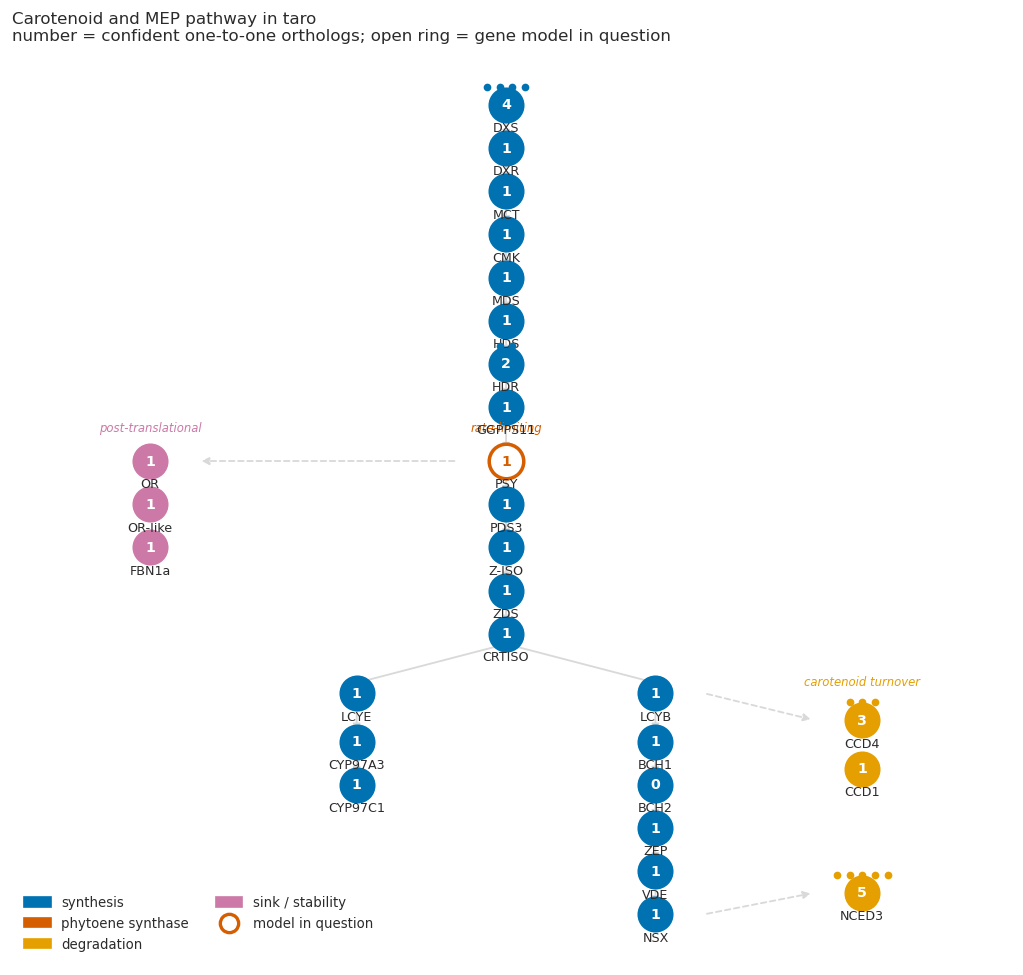


expanded steps:
  NCED3     5
  DXS       4
  CCD4      3
  HDR       2

One synthesis gene at the rate-limiting step; three CCD4 at the
degradation step. Copy number is not flux: nothing here measures
expression or activity in corm.


In [2]:
conf = ph[ph.call == "ortholog (RBH)"]
n = conf.groupby("gene").size().to_dict()

# role decides colour; this is a categorical assignment in fixed order
SYNTH, DEGRADE, SINK, FOCAL = "synthesis", "degradation", "sink", "focal"
ROLE = {SYNTH: BLUE, DEGRADE: ORANGE, SINK: PURPLE, FOCAL: VERMILLION}

# (gene, x, y, role).  Layout follows the pathway, not the alphabet.
NODES = [
    ("DXS",     0.0,  9.0, SYNTH), ("DXR",   0.0,  8.2, SYNTH),
    ("MCT",     0.0,  7.4, SYNTH), ("CMK",   0.0,  6.6, SYNTH),
    ("MDS",     0.0,  5.8, SYNTH), ("HDS",   0.0,  5.0, SYNTH),
    ("HDR",     0.0,  4.2, SYNTH), ("GGPPS11", 0.0, 3.4, SYNTH),
    ("PSY",     0.0,  2.4, FOCAL),
    ("PDS3",    0.0,  1.6, SYNTH), ("Z-ISO", 0.0,  0.8, SYNTH),
    ("ZDS",     0.0,  0.0, SYNTH), ("CRTISO", 0.0, -0.8, SYNTH),
    ("LCYE",   -1.3, -1.9, SYNTH), ("LCYB",  1.3, -1.9, SYNTH),
    ("CYP97A3",-1.3, -2.8, SYNTH), ("BCH1",  1.3, -2.8, SYNTH),
    ("CYP97C1",-1.3, -3.6, SYNTH), ("BCH2",  1.3, -3.6, SYNTH),
    ("ZEP",     1.3, -4.4, SYNTH), ("VDE",   1.3, -5.2, SYNTH),
    ("NSX",     1.3, -6.0, SYNTH),
    ("CCD4",    3.1, -2.4, DEGRADE), ("CCD1", 3.1, -3.3, DEGRADE),
    ("NCED3",   3.1, -5.6, DEGRADE),
    ("OR",     -3.1,  2.4, SINK), ("OR-like", -3.1, 1.6, SINK),
    ("FBN1a",  -3.1,  0.8, SINK),
]
POS = {g: (x, y) for g, x, y, _ in NODES}

EDGES = [("DXS","DXR"),("DXR","MCT"),("MCT","CMK"),("CMK","MDS"),
         ("MDS","HDS"),("HDS","HDR"),("HDR","GGPPS11"),("GGPPS11","PSY"),
         ("PSY","PDS3"),("PDS3","Z-ISO"),("Z-ISO","ZDS"),("ZDS","CRTISO"),
         ("CRTISO","LCYE"),("CRTISO","LCYB"),
         ("LCYE","CYP97A3"),("CYP97A3","CYP97C1"),
         ("LCYB","BCH1"),("BCH1","BCH2"),("BCH2","ZEP"),("ZEP","VDE"),
         ("VDE","NSX")]

# loci whose gene model is in question, from 13_ and 16_
QUESTIONED = {"PSY"}

fig, ax = plt.subplots(figsize=(8.6, 8.2))

for a, b in EDGES:
    (x1, y1), (x2, y2) = POS[a], POS[b]
    ax.annotate("", xy=(x2, y2 + 0.19), xytext=(x1, y1 - 0.19),
                arrowprops=dict(arrowstyle="-|>", color=FAINT, lw=1.1,
                                shrinkA=0, shrinkB=0))

# degradation and sink act on the pathway rather than within it
for src, dst, lab in [("LCYB", "CCD4", "cleaves"), ("NSX", "NCED3", ""),
                      ("PSY", "OR", "stabilises")]:
    (x1, y1), (x2, y2) = POS[src], POS[dst]
    ax.annotate("", xy=(x2 + (0.42 if x2 < x1 else -0.42), y2),
                xytext=(x1 + (-0.42 if x2 < x1 else 0.42), y1),
                arrowprops=dict(arrowstyle="-|>", color=FAINT, lw=1.1,
                                linestyle=(0, (3, 2))))

for g, x, y, role in NODES:
    k = n.get(g, 0)
    face = ROLE[role]
    open_ring = g in QUESTIONED
    ax.scatter([x], [y], s=430, facecolor="white" if open_ring else face,
               edgecolor=face, linewidth=2.1 if open_ring else 0.9, zorder=3)
    ax.text(x, y, str(k), ha="center", va="center", fontsize=8.5,
            color=face if open_ring else "white", fontweight="bold", zorder=4)
    ax.text(x, y - 0.33, g, ha="center", va="top", fontsize=7.6,
            color=INK, zorder=4)
    # copy number above one is worth seeing without reading the digit
    if k > 1:
        for i in range(k):
            ax.scatter([x - 0.055 * (k - 1) + 0.11 * i], [y + 0.33],
                       s=13, color=face, zorder=4)

ax.text(0.0, 2.95, "rate-limiting", ha="center", fontsize=7,
        color=VERMILLION, style="italic")
ax.text(3.1, -1.75, "carotenoid turnover", ha="center", fontsize=7,
        color=ORANGE, style="italic")
ax.text(-3.1, 2.95, "post-translational", ha="center", fontsize=7,
        color=PURPLE, style="italic")

ax.set_xlim(-4.3, 4.4); ax.set_ylim(-6.9, 10.0)
ax.axis("off")
ax.set_title("Carotenoid and MEP pathway in taro\n"
             "number = confident one-to-one orthologs; "
             "open ring = gene model in question",
             fontsize=10, loc="left", color=INK)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,       label="synthesis"),
    mpatches.Patch(color=VERMILLION, label="phytoene synthase"),
    mpatches.Patch(color=ORANGE,     label="degradation"),
    mpatches.Patch(color=PURPLE,     label="sink / stability"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor=VERMILLION, markeredgewidth=2, markersize=11,
           label="model in question"),
], frameon=False, fontsize=8, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

print("\nexpanded steps:")
for g, k in sorted(n.items(), key=lambda x: -x[1]):
    if k > 1:
        print(f"  {g:<9} {k}")
print("\nOne synthesis gene at the rate-limiting step; three CCD4 at the")
print("degradation step. Copy number is not flux: nothing here measures")
print("expression or activity in corm.")

## 2. The evidence behind every node

Each point in the landscape rests on a reciprocal best hit with an identity
and a coverage. Showing that plane is the audit trail: a reader can see which
calls are comfortable and which sit near a threshold, rather than taking the
dot counts on trust.

The Wilcoxon signed-rank test asks whether coverage departs from parity with
the Arabidopsis query. It matters because if the taro annotation truncated
models systematically, the PSY fragments would be typical rather than
exceptional — and the whole premise of Part 2 would be weaker.

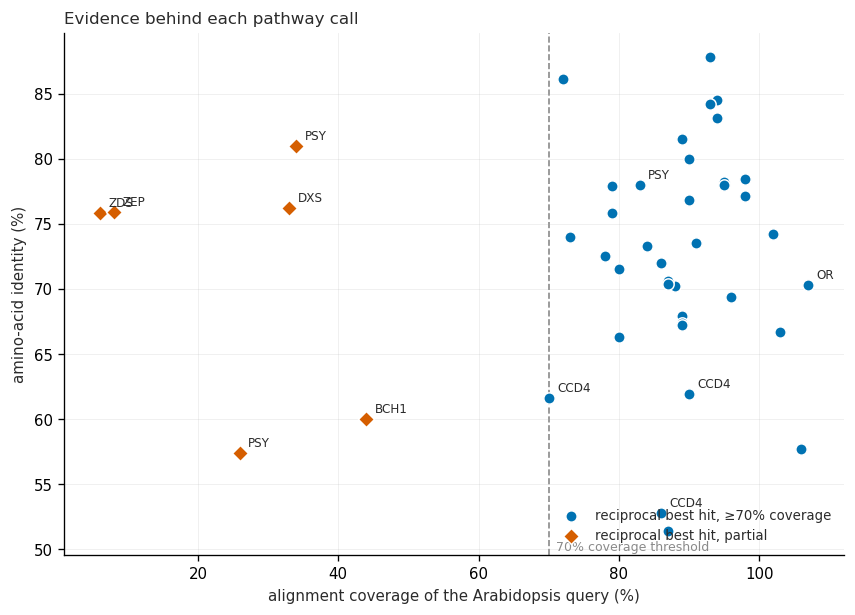

n = 37 one-to-one orthologs
median coverage 89.0%  (bootstrap 95% CI 87.0–93.0%)
Wilcoxon signed-rank vs parity: W = 28.0, p = 0.0000

A median at or above parity means coverage is not systematically
truncated, so the PSY fragments are the exception. That is what
licenses treating them as a case study rather than as the norm.


In [3]:
d = ph[ph.call.isin(["ortholog (RBH)", "partial (RBH)"])].dropna(
    subset=["coverage_pct", "identity"]).copy()

fig, ax = plt.subplots(figsize=(7.2, 5.2))

for call, colour, marker, lab in [
        ("ortholog (RBH)", BLUE,       "o", "reciprocal best hit, ≥70% coverage"),
        ("partial (RBH)",  VERMILLION, "D", "reciprocal best hit, partial")]:
    s = d[d.call == call]
    ax.scatter(s.coverage_pct, s.identity, s=46, c=colour, marker=marker,
               edgecolor="white", linewidth=0.9, label=lab, zorder=3)

ax.axvline(70, color=MUTED, ls="--", lw=1, zorder=1)
ax.text(71, d.identity.min() - 1.5, "70% coverage threshold",
        fontsize=7.5, color=MUTED)

# label only what the reader needs, never every point
for r in d.itertuples():
    if r.coverage_pct < 70 or r.gene in ("PSY", "CCD4", "OR"):
        ax.annotate(f"{r.gene}", (r.coverage_pct, r.identity), fontsize=7.2,
                    xytext=(5, 4), textcoords="offset points", color=INK)

ax.set_xlabel("alignment coverage of the Arabidopsis query (%)")
ax.set_ylabel("amino-acid identity (%)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title("Evidence behind each pathway call", fontsize=10, loc="left")
plt.tight_layout()
plt.show()

cov = d[d.call == "ortholog (RBH)"].coverage_pct / 100
w, p = stats.wilcoxon(cov - 1)
lo, hi = np.percentile(
    [np.median(np.random.choice(cov, len(cov))) for _ in range(5000)], [2.5, 97.5])
print(f"n = {len(cov)} one-to-one orthologs")
print(f"median coverage {cov.median()*100:.1f}%  "
      f"(bootstrap 95% CI {lo*100:.1f}–{hi*100:.1f}%)")
print(f"Wilcoxon signed-rank vs parity: W = {w:.1f}, p = {p:.4f}")
print()
print("A median at or above parity means coverage is not systematically")
print("truncated, so the PSY fragments are the exception. That is what")
print("licenses treating them as a case study rather than as the norm.")

## 3. Locus architecture — artifact or duplication

Two pairs of adjacent gene identifiers, two different answers. This is the
panel that carries Part 1 into Part 2, because it shows a concrete locus the
published annotation cannot resolve.

Flanking genes are drawn from the GFF3 as arrows so the reader can see that
the PSY pair really is uninterrupted, rather than taking the 259 bp figure on
trust.

/home/ha-ibnu/Code/taro/.tmp/ipykernel_621650/793121773.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.arrow(s - origin if strand == "+" else e - origin, 0,


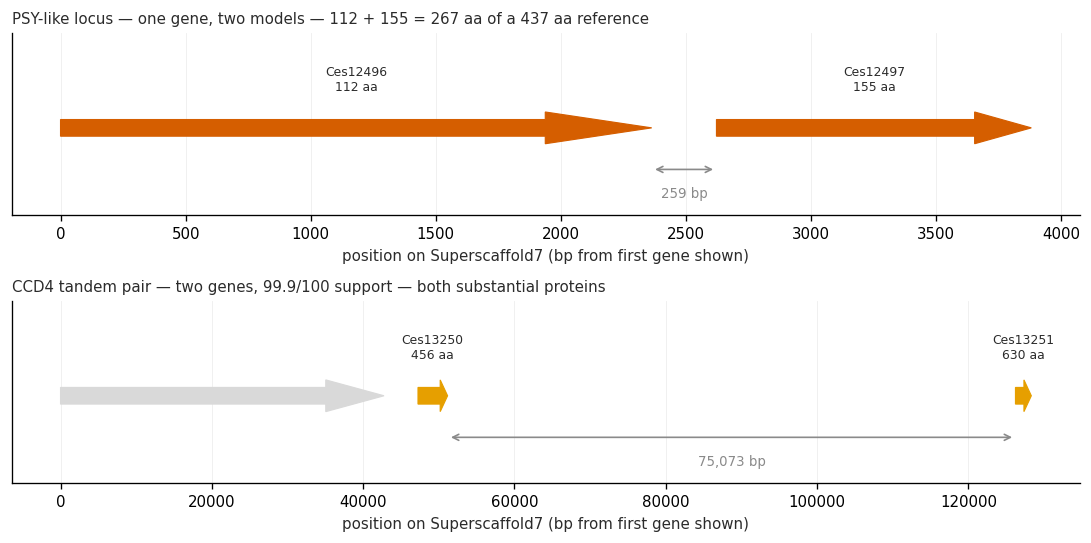

Same adjacency signal, opposite answers. 259 bp with nothing between
and complementary protein fragments is a split model; 75 kb apart with
two substantial proteins is a tandem duplication.


In [4]:
def genes_near(scaffold, lo, hi, pad=12000):
    rows = []
    with open(GFF) as fh:
        for ln in fh:
            if ln.startswith("#"):
                continue
            f = ln.rstrip("\n").split("\t")
            if len(f) < 9 or f[0] != scaffold or f[2] != "gene":
                continue
            s, e = int(f[3]), int(f[4])
            if e >= lo - pad and s <= hi + pad:
                m = re.search(r"ID=(?:gene-)?([^;]+)", f[8])
                rows.append((m.group(1) if m else "?", s, e, f[6]))
    return sorted(rows, key=lambda r: r[1])


PANELS = [
    ("PSY-like locus", "Superscaffold7", 79_028_474, 79_032_356,
     {"Ces12496": 112, "Ces12497": 155}, VERMILLION,
     "one gene, two models — 112 + 155 = 267 aa of a 437 aa reference"),
    ("CCD4 tandem pair", "Superscaffold7", 99_656_322, 99_737_395,
     {"Ces13250": 456, "Ces13251": 630}, ORANGE,
     "two genes, 99.9/100 support — both substantial proteins"),
]

fig, axes = plt.subplots(2, 1, figsize=(9.2, 4.6))
for ax, (title, scaf, lo, hi, focal, colour, note) in zip(axes, PANELS):
    try:
        ctx = genes_near(scaf, lo, hi)
    except FileNotFoundError:
        ctx = [(g, lo, hi, "+") for g in focal]
        note += "   (GFF3 not found; flanking genes omitted)"
    origin = min(s for _, s, _, _ in ctx) if ctx else lo
    for gid, s, e, strand in ctx:
        hit = next((f for f in focal if f in gid), None)
        c = colour if hit else FAINT
        w = e - s
        ax.arrow(s - origin if strand == "+" else e - origin, 0,
                 w if strand == "+" else -w, 0,
                 width=0.22, head_width=0.42,
                 head_length=max(w * 0.18, (hi - lo) * 0.012),
                 length_includes_head=True, color=c,
                 edgecolor="white", linewidth=0.7, zorder=3 if hit else 2)
        if hit:
            ax.text((s + e) / 2 - origin, 0.46, f"{hit}\n{focal[hit]} aa",
                    ha="center", va="bottom", fontsize=7.4, color=INK)

    fa = [(s, e) for g, s, e, _ in ctx if any(f in g for f in focal)]
    if len(fa) == 2:
        gap = fa[1][0] - fa[0][1]
        ax.annotate("", xy=(fa[0][1] - origin, -0.55),
                    xytext=(fa[1][0] - origin, -0.55),
                    arrowprops=dict(arrowstyle="<->", color=MUTED, lw=1))
        ax.text((fa[0][1] + fa[1][0]) / 2 - origin, -0.78, f"{gap:,} bp",
                ha="center", va="top", fontsize=8, color=MUTED)

    ax.set_ylim(-1.15, 1.25)
    ax.set_yticks([])
    ax.set_xlabel(f"position on {scaf} (bp from first gene shown)")
    ax.set_title(f"{title} — {note}", fontsize=9, loc="left")
    ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

print("Same adjacency signal, opposite answers. 259 bp with nothing between")
print("and complementary protein fragments is a split model; 75 kb apart with")
print("two substantial proteins is a tandem duplication.")

## 4. What the phylogeny can and cannot resolve

Reporting a tree without its support is a drawing, not evidence. This plots
support along the path from each taro gene outward, which is the only form of
the question that matters: not how well resolved the tree is on average, but
whether the specific nodes a claim rests on are supported.

The contrast is the point. The CCD4 tandem pair sits at maximal support; the
PSY backbone does not clear the threshold anywhere.

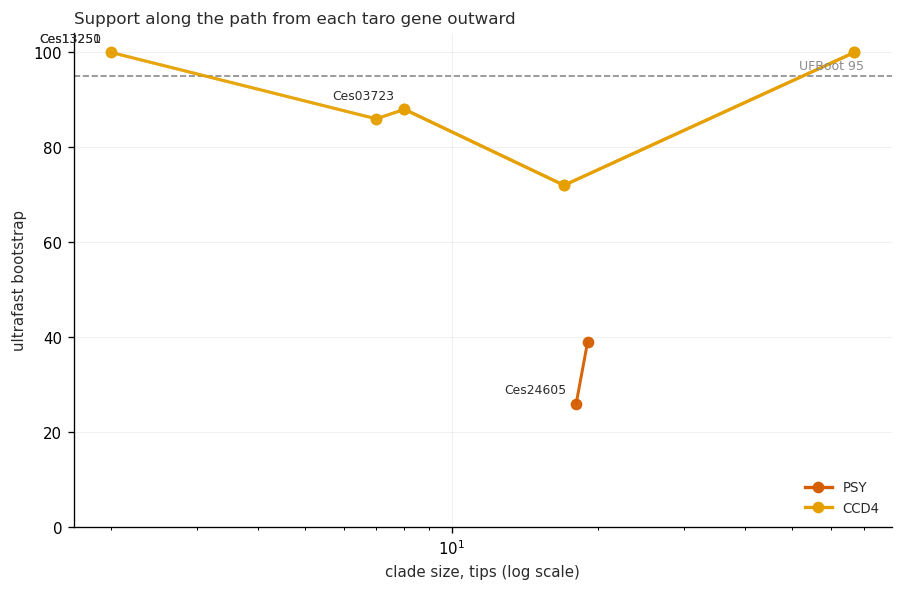

The CCD4 tandem pair is resolved at maximal support; the PSY
backbone is not resolved anywhere. Both statements belong in the
paper, and the second constrains what the first can be used for.


In [5]:
ALRT_MIN, BOOT_MIN = 80.0, 95

def support_path(tree_file, prefix):
    from Bio import Phylo
    t = Phylo.read(str(tree_file), "newick")
    t.root_at_midpoint()
    out = []
    for tip in [l for l in t.get_terminals() if l.name and l.name.startswith(prefix)]:
        rows = []
        for nd in reversed(t.get_path(tip)[:-1]):
            raw = nd.name or (str(nd.confidence) if nd.confidence is not None else "")
            m = re.match(r"^([\d.]+)/(\d+)$", str(raw).strip())
            if not m:
                continue
            a, b = float(m.group(1)), int(m.group(2))
            rows.append((len(nd.get_terminals()), a, b))
            if len(nd.get_terminals()) > 24:
                break
        out.append((tip.name.split("_", 1)[1], rows))
    return out

series = []
for fam, f, label in [("PSY", TREES / "psy_iq.treefile", "PSY"),
                      ("CCD", TREES / "ccd_iq.treefile", "CCD4 / NCED")]:
    if f.exists():
        for gene, rows in support_path(f, "colesc"):
            if rows:
                series.append((label, gene, rows))

if not series:
    print("no IQ-TREE trees found; run 17_ first")
else:
    fig, ax = plt.subplots(figsize=(7.6, 5.0))
    shown = [s for s in series if s[1] in
             ("Ces24605", "Ces13250", "Ces13251", "Ces03723")]
    for i, (fam, gene, rows) in enumerate(shown):
        sizes = [r[0] for r in rows]
        boot  = [r[2] for r in rows]
        c = VERMILLION if fam == "PSY" else ORANGE
        ax.plot(sizes, boot, marker="o", ms=6, lw=1.8, color=c,
                alpha=0.95 if fam == "PSY" else 0.75, zorder=3)
        ax.annotate(gene, (sizes[0], boot[0]), fontsize=7.4,
                    xytext=(-6, 6), textcoords="offset points",
                    ha="right", color=INK)

    ax.axhline(BOOT_MIN, color=MUTED, ls="--", lw=1)
    ax.text(ax.get_xlim()[1], BOOT_MIN + 1.5, f"UFBoot {BOOT_MIN}",
            ha="right", fontsize=7.5, color=MUTED)
    ax.set_xscale("log")
    ax.set_xlabel("clade size, tips (log scale)")
    ax.set_ylabel("ultrafast bootstrap")
    ax.set_ylim(0, 104)
    ax.legend(handles=[
        Line2D([0], [0], color=VERMILLION, lw=2, marker="o", label="PSY"),
        Line2D([0], [0], color=ORANGE, lw=2, marker="o", label="CCD4"),
    ], frameon=False, fontsize=8, loc="lower right")
    ax.set_title("Support along the path from each taro gene outward",
                 fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()

    print("The CCD4 tandem pair is resolved at maximal support; the PSY")
    print("backbone is not resolved anywhere. Both statements belong in the")
    print("paper, and the second constrains what the first can be used for.")

## What carries forward

Panel 1 is the manuscript figure. It is Figure 4 in the corrected
architecture, not Figure 1, because the pathway inventory motivates this work
rather than being its subject.

Panels 2 to 4 are the evidence that licenses it, and belong in supplementary
material or a methods section.

## What Part 2 needs that does not exist yet

A null model. "Reference choice changed N% of transcript models" cannot be
interpreted without knowing how much changes when nothing changes. Resample
the reads, map to the same reference, rebuild the models, and measure the
churn. That baseline has to be designed in before any mapping is run, not
added afterwards.

Two consequences of the design follow from it. The comparison is paired, the
same transcript under two references, so a change in structural category is
tested with McNemar rather than chi-square. And recovery proportions sit near
one, where the normal approximation misbehaves, so confidence intervals
should be Wilson.